In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
df = pd.read_csv("../data/weather_hourly_avg.csv", parse_dates=["datetime_utc"])
df = df.sort_values("datetime_utc").reset_index(drop=True)

In [3]:
df['GHI_next_day'] = df['GHI'].shift(-24)

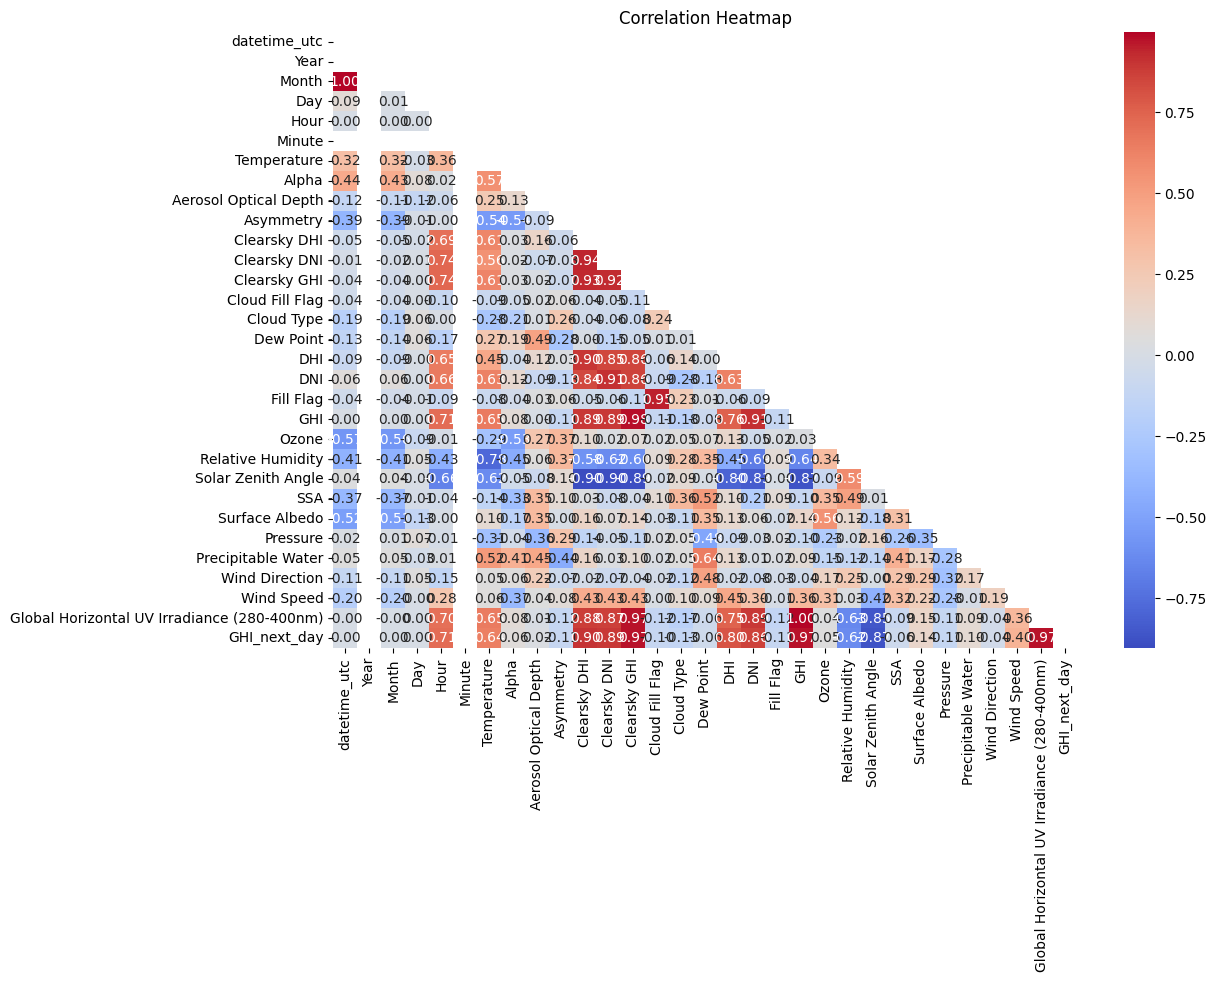

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), mask=mask, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
features = [
    "Temperature", "Dew Point", "Relative Humidity", "Pressure", 
    "Wind Speed", "Wind Direction", "Clearsky GHI", "Clearsky DNI", "Clearsky DHI", "DNI", "Hour", "Month", "GHI"]

X = df[features]
y = df['GHI_next_day']

# Drop rows with missing target (the last 24 rows)
X = X.iloc[:-24, :]
y = y.iloc[:-24]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [10]:
X.to_csv("../data/X_irr.csv", index=False)
y.to_csv("../data/y_irr.csv", index=False)

# Linear Regression Prediction

In [13]:
# Train linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.2f}")

r2 = r2_score(y_test, y_pred)
print(f"r2: {r2:.2f}")

MSE: 1679.22
r2: 0.97


In [69]:
X_next_day = X.tail(24)

# Predict next day GHI
GHI_next_24h = model.predict(X_next_day)
print(GHI_next_24h)

[ 46.79176423  27.08733234  27.70217878  26.64603191  27.37762301
  27.96719056  28.07043984  27.26008568  25.78230246  23.93701931
  22.5088209   21.65624796  20.96581274  20.48950285  19.86498088
  78.72709118 222.68374327 358.34744522 477.1962597  545.41417198
 544.31339963 473.84214623 347.96287812 182.37323681]


In [70]:
hourly_avg_next_day = df.groupby('Hour')['GHI_next_day'].mean().reset_index()
hourly_avg_next_day

,Hour,GHI_next_day
0,0.0,218.726771
1,1.0,79.621697
2,2.0,9.280770
3,3.0,0.000000
4,4.0,0.000000
5,5.0,0.000000
6,6.0,0.000000
7,7.0,0.000000
8,8.0,0.000000
9,9.0,0.000000


In [71]:
X.tail(24)['GHI']

8736     37.610215
8737      0.000000
8738      0.000000
8739      0.000000
8740      0.000000
8741      0.000000
8742      0.000000
8743      0.000000
8744      0.000000
8745      0.000000
8746      0.000000
8747      0.000000
8748      0.000000
8749      0.000000
8750      0.000000
8751     86.123656
8752    228.927419
8753    353.838710
8754    492.919355
8755    585.000000
8756    591.642473
8757    516.524194
8758    384.467742
8759    211.564516
Name: GHI, dtype: float64

# KNN Prediction

In [72]:
features = [
    "Temperature", "Dew Point", "Relative Humidity", "Pressure", 
    "Wind Speed", "Wind Direction", "Clearsky GHI", "Clearsky DNI", "Clearsky DHI", "DNI", "Hour", "Month", "GHI", "Solar Zenith Angle"
]

X = df[features]
y = df['GHI_next_day']

# Drop rows with missing target (the last 24 rows)
X = X.iloc[:-24, :]
y = y.iloc[:-24]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [73]:
knn = KNeighborsRegressor(n_neighbors=5)   # you can tune K later
knn.fit(X_train, y_train)

# === Predict ===
pred = knn.predict(X_test)

# === Evaluation ===
print("MSE:", mean_squared_error(y_test, pred))

MSE: 2784.1263407875103


In [74]:
best_k, best_mse = None, float("inf")

for k in range(1,40):
    knn = KNeighborsRegressor(n_neighbors=k)   # you can tune K later
    knn.fit(X_train, y_train)
    y_preds = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_preds)

    if mse < best_mse:
        best_mse = mse
        best_k = k

print("Best k:", best_k)
print("Best MSE:", best_mse)

Best k: 39
Best MSE: 1978.4664789572096


In [75]:
X_next_day = X.tail(24)

# Predict next day GHI
GHI_next_24h = knn.predict(X_next_day)
print(GHI_next_24h)

[5.08939206e+01 2.01268266e-02 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 6.20347395e-04 9.84750482e+01
 2.25613248e+02 3.66014544e+02 5.00107803e+02 5.01792115e+02
 4.96700234e+02 4.79098704e+02 3.58412255e+02 2.13578095e+02]


In [76]:
X.tail(24)['GHI']

8736     37.610215
8737      0.000000
8738      0.000000
8739      0.000000
8740      0.000000
8741      0.000000
8742      0.000000
8743      0.000000
8744      0.000000
8745      0.000000
8746      0.000000
8747      0.000000
8748      0.000000
8749      0.000000
8750      0.000000
8751     86.123656
8752    228.927419
8753    353.838710
8754    492.919355
8755    585.000000
8756    591.642473
8757    516.524194
8758    384.467742
8759    211.564516
Name: GHI, dtype: float64

# Decision Tree (to see if ORT is worth trying)

In [77]:
tree = DecisionTreeRegressor(
    max_depth=4,        # try 3–6
    min_samples_leaf=50 # tune this too
)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
print("Tree MSE:", mean_squared_error(y_test, pred_tree))

Tree MSE: 2244.785670434876


# Random Forest

In [78]:
rf = RandomForestRegressor(
    n_estimators=300,        # number of trees (tune later)
    max_depth=None,         # allow trees to fully grow first
    min_samples_leaf=5,     # smooths noise, important for time-series
    random_state=42,        # reproducible
    n_jobs=-1               # use all cores
)

rf.fit(X_train, y_train)

# ---- Predict + Evaluate ----
rf_pred = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

# ---- Feature Importance ----
#importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
#print("\nFeature Importance:")
#print(importances)

Random Forest MSE: 1912.58556378419


# XGBoost

In [79]:
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=10
)

gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_test)

print("Gradient Boosting MSE:", mean_squared_error(y_test, gbr_pred))

Gradient Boosting MSE: 1729.9591913970964
